# Experiment 1: Prompt concept A/B

Two prompt concepts are compared. Model, texts and reps are frozen; only the prompt varies.

| arm | prompt |
|---|---|
| **a** | original: "land **use**" framing, plus an instruction to infer land type from regional context |
| **b** | rewrite: "land **cover**" framing (the taxonomy is CORINE Land *Cover*), regional-inference instruction removed |

### Prediction

The change is expected to be subset-specific rather than uniform: `b` should lower confidence
on **thin-text** rows (place name only, where the model has little to go on) while leaving
rich-text rows roughly unchanged. A flat overall average would not be evidence against this.

In [7]:
import sys
import os
import pandas as pd
sys.path.insert(0, os.path.abspath('../..'))

from testing.util.analysis import cells_of, load_reference, guard, calibration
from testing.util.process import process_csv
from testing.util.prompt_ab import build_a, build_b
from testing.util.config import WORKING_DATA, RESULT_PATH
from testing.util.plots import plot_confidence_hist, plot_confidence_by_difficulty

from app.config import DEFAULT_MODEL
from app.util.pricing import calc_pricing
from app.util.gee_mapping import get_clc_mapping

INPUT = WORKING_DATA
MODEL = DEFAULT_MODEL                                   # frozen
VARIANTS = {'a': build_a(), 'b': build_b()}             # the only axis that varies
REPS = 5
EXP_PATH = f'{RESULT_PATH}/exp1'
OUTPUT = f'{EXP_PATH}/exp1_output.csv'

get_clc_mapping(INPUT, f'{EXP_PATH}/corine_output.csv')
REF = load_reference(f'{EXP_PATH}/corine_output.csv')

df = pd.read_csv(INPUT, dtype={'row_id': str})
assert df['row_id'].notna().all() and df['row_id'].is_unique
print(len(df), 'rows |', df['difficulty_tag'].value_counts().to_dict())

20 rows | {'unambiguous_candidate': 7, 'boundary_candidate': 6, 'thin': 4, 'edge_no_signal': 2, 'edge_cultivated': 1}


In [8]:
async def run_arm(df, prompt, variant, reps):
    """Stamps row_id, variant and rep on every result. The variant stamp matters:
    without it the output does not record which prompt produced it, and the two
    arms cannot be told apart afterwards."""
    frames = []
    for rep in range(reps):
        r = await process_csv(df, MODEL, version=0, prompt=prompt)
        assert len(r) == len(df), 'row count changed — cannot align by position'
        r['row_id'], r['difficulty'] = df['row_id'].values, df['difficulty_tag'].values
        r['variant'], r['rep'] = variant, rep
        frames.append(r)
    return pd.concat(frames, ignore_index=True)

raw = pd.concat([await run_arm(df, p, name, REPS) for name, p in VARIANTS.items()],
                ignore_index=True)
raw.to_csv(OUTPUT, index=False)
print('wrote', OUTPUT, '|', raw.shape)

wrote /home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/results/exp1/exp1_output.csv | (200, 32)


In [12]:
raw = pd.read_csv(OUTPUT, dtype={'id': str, 'clc_code': str})

for v in VARIANTS:
    guard(raw[raw.variant == v], expect_variant='v0', expect_model=MODEL, label=f'arm {v}')
assert raw['variant'].nunique() == len(VARIANTS)
print('guards passed |', raw['clc_model'].iloc[0])

guards passed | gpt-5.4-nano


### The subset-specific comparison

Confidence and consistency are split by text richness. The expectation is a drop on thin
rows and little movement on rich rows.

In [13]:
cells = pd.concat([cells_of(raw[raw.variant == v], REF).assign(variant=v)
                   for v in VARIANTS], ignore_index=True)
LOW = {'thin', 'edge_no_signal', 'edge_cultivated'}
cells['richness'] = cells['difficulty'].map(lambda d: 'thin' if d in LOW else 'rich')

for metric in ['mean_conf', 'consistency', 'agree_L1']:
    print(metric)
    print(cells.pivot_table(index='richness', columns='variant',
                            values=metric, aggfunc='mean').round(3), '\n')

mean_conf
variant       a      b
richness              
rich      0.622  0.474
thin      0.391  0.190 

consistency
variant       a      b
richness              
rich      0.969  0.985
thin      0.886  0.829 

agree_L1
variant          a         b
richness                    
rich      0.363636  0.363636
thin           0.5       0.5 



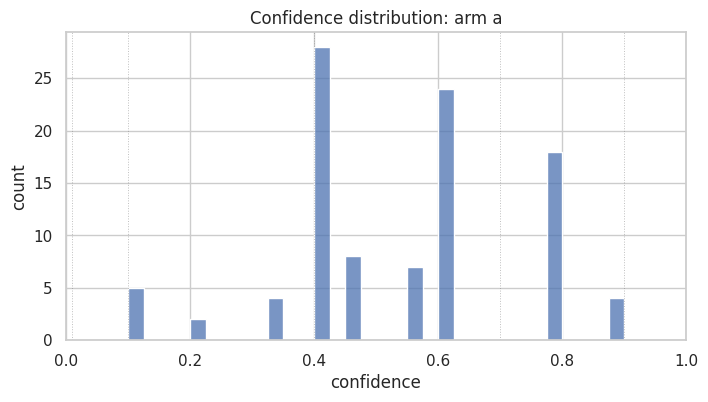

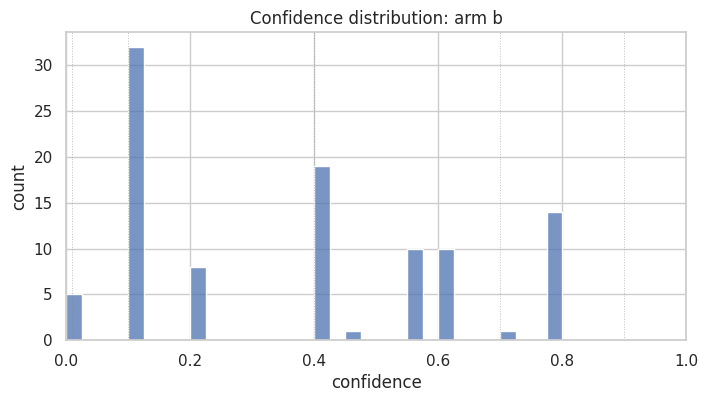

In [14]:
for v in VARIANTS:
    plot_confidence_hist(raw[raw.variant == v], f'Confidence distribution: arm {v}')

/home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/util/plots.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_short(d) for d in order])


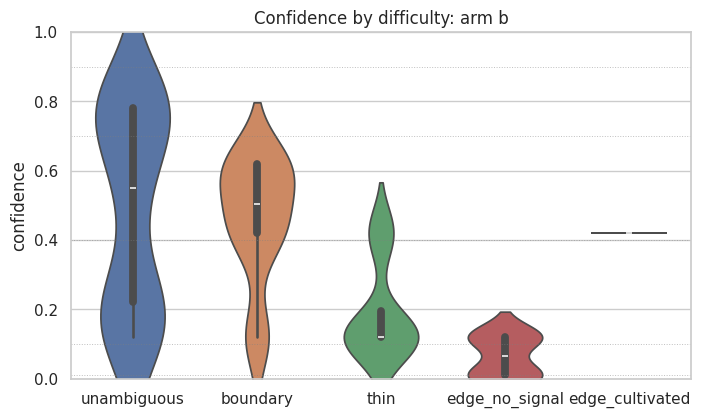

In [17]:
plot = plot_confidence_by_difficulty(raw[raw.variant == 'b'],'Confidence by difficulty: arm b')

### Did the codes move?

If the two arms produce largely the same codes, then agreement with the reference cannot separate them. Any difference would have to show up in confidence or consistency instead.

In [16]:
a = cells[cells.variant == 'a'].set_index('id')
b = cells[cells.variant == 'b'].set_index('id')
same = (a['modal_code'] == b['modal_code']).sum()
print(f'{same}/{len(a)} rows kept the same modal code across the two arms')

18/20 rows kept the same modal code across the two arms


In [18]:
cells = pd.concat([cells_of(raw[raw.variant == v], REF).assign(variant=v)
                   for v in VARIANTS], ignore_index=True)
LOW = {'thin', 'edge_no_signal', 'edge_cultivated'}
cells['richness'] = cells['difficulty'].map(lambda d: 'thin' if d in LOW else 'rich')

for metric in ['mean_conf', 'consistency', 'agree_L1']:
    print(metric)
    print(cells.pivot_table(index='richness', columns='variant',
                            values=metric, aggfunc='mean').round(3), '\n')

mean_conf
variant       a      b
richness              
rich      0.622  0.474
thin      0.391  0.190 

consistency
variant       a      b
richness              
rich      0.969  0.985
thin      0.886  0.829 

agree_L1
variant          a         b
richness                    
rich      0.363636  0.363636
thin           0.5       0.5 



## Conclusion

- **Carried forward:** `B`
- **Thin-row confidence:** A = 0.391 -> B = 0.190
- **Thin-row consistency:** A = 0.886 -> B = 0.829
- **Rich rows:** Stayed roughly similar across arms. A has a slight edge.
- **Codes moved:** 2 / 20 codes changed across versions.

Codes did not move much. We decided to go with B, as it met our expectations well (lower thin-row confidence, comparable when rich)